In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import pandas as pd
customers_data = pd.read_csv("Mall_Customers.csv")
customers_data

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

In [ ]:
customers_data = pd.read_csv("Mall_Customers.csv")
customers_data

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

In [ ]:
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X = data.data  # Features
y = data.target  # Labels

print(f"Shape: {X.shape}")
print(f"Features: {data.feature_names}")
print(f"Classes: {data.target_names}")

Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [ ]:
from sklearn.datasets import load_wine

# Load dataset
data = load_wine()
X = data.data  # Features
y = data.target  # Labels

print(f"Shape: {X.shape}")
print(f"Features: {data.feature_names}")
print(f"Classes: {data.target_names}")

Shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']


/tmp/ipython-input-4184504887.py:31: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum(errors ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-4184504887.py:43: RuntimeWarning: invalid value encountered in scalar subtract
  self.theta1 -= self.learning_rate * gradient_theta1


Learned Parameters:
  Intercept (θ₀): nan
  Slope (θ₁): nan

Predictions vs Actual:
  X=1000: Predicted=nan, Actual=150000
  X=1500: Predicted=nan, Actual=200000
  X=2000: Predicted=nan, Actual=280000
  X=2500: Predicted=nan, Actual=350000
  X=3000: Predicted=nan, Actual=420000


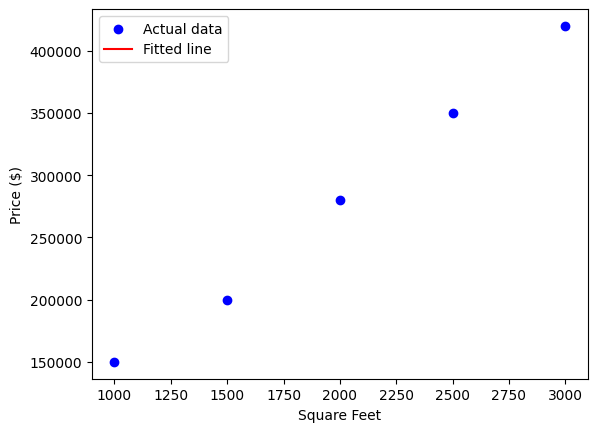

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionFromScratch:
    """Linear Regression implemented from scratch using NumPy."""

    def __init__(self, learning_rate=0.01, iterations=1000):
        # learning_rate: controls how big each step is during training
        # iterations: how many times we update our parameters
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.theta0 = 0  # intercept (y-intercept of the line)
        self.theta1 = 0  # slope (steepness of the line)
        self.cost_history = []  # track cost over iterations

    def fit(self, X, y):
        """Train the model on data X and labels y."""
        m = len(X)  # number of training examples

        # Repeat the learning process for specified iterations
        for iteration in range(self.iterations):
            # Step 1: Make predictions using current parameters
            # y_pred = theta0 + theta1 * X
            y_pred = self.theta0 + self.theta1 * X

            # Step 2: Calculate errors (difference between predicted and actual)
            errors = y_pred - y

            # Step 3: Calculate cost (Mean Squared Error)
            # Cost = (1/2m) * sum(errors²)
            cost = (1 / (2 * m)) * np.sum(errors ** 2)
            self.cost_history.append(cost)

            # Step 4: Calculate gradients (direction and magnitude of change)
            # Gradient for theta0 = (1/m) * sum(errors)
            gradient_theta0 = (1 / m) * np.sum(errors)
            # Gradient for theta1 = (1/m) * sum(errors * X)
            gradient_theta1 = (1 / m) * np.sum(errors * X)

            # Step 5: Update parameters using gradients
            # Move in opposite direction of gradient to minimize cost
            self.theta0 -= self.learning_rate * gradient_theta0
            self.theta1 -= self.learning_rate * gradient_theta1

        return self

    def predict(self, X):
        """Make predictions on new data."""
        # Use learned parameters to predict: y = theta0 + theta1 * X
        return self.theta0 + self.theta1 * X

    def get_parameters(self):
        """Return learned parameters."""
        return {'intercept': self.theta0, 'slope': self.theta1}

# Example usage
if __name__ == '__main__':
    # Sample data: house sizes and prices
    X = np.array([1000, 1500, 2000, 2500, 3000])  # square feet
    y = np.array([150000, 200000, 280000, 350000, 420000])  # prices

    # Create and train model
    model = LinearRegressionFromScratch(learning_rate=0.00001, iterations=1000)
    model.fit(X, y)

    # Make predictions
    predictions = model.predict(X)

    # Print results
    print('Learned Parameters:')
    params = model.get_parameters()
    print(f'  Intercept (θ₀): {params["intercept"]:.2f}')
    print(f'  Slope (θ₁): {params["slope"]:.2f}')
    print(f'\nPredictions vs Actual:')
    for i in range(len(X)):
        print(f'  X={X[i]}: Predicted={predictions[i]:.0f}, Actual={y[i]}')

    # Visualize
    plt.scatter(X, y, color='blue', label='Actual data')
    plt.plot(X, predictions, color='red', label='Fitted line')
    plt.xlabel('Square Feet')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.show()


In [1]:
import numpy as np

class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.theta = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        X = np.c_[np.ones(m), X]
        self.theta = np.zeros(n + 1)
        for _ in range(self.iterations):
            h = self.sigmoid(X @ self.theta)
            gradient = (1/m) * X.T @ (h - y)
            self.theta -= self.lr * gradient
        return self

    def predict(self, X):
        m = X.shape[0]
        X = np.c_[np.ones(m), X]
        return (self.sigmoid(X @ self.theta) >= 0.5).astype(int)

In [2]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)
preds = model.predict(X)

NameError: name 'X' is not defined